In [1]:
import pandas as pd
import matplotlib.pyplot as plt


# Loading in modeling dataset
df = pd.read_csv("../processed/modeling_dataset.csv")

df.head()


,play_id,nfl_id,A,S,E,Eyes,Innovation,Improv,player_side,game_id,...,pass_result,pass_length,route_of_targeted_receiver,team_coverage_man_zone,yards_gained,expected_points,expected_points_added,throw_frame,PER10,PER10360
0,3696,46150,6.0,5.5,8.0,6.5,4.5,3.5,Offense,2023092410,...,C,8,SLANT,ZONE_COVERAGE,10,4.786310,-0.105650,19,6,6
1,540,53541,5.5,6.0,7.0,5.0,4.0,3.5,Offense,2023092402,...,C,10,HITCH,MAN_COVERAGE,15,1.743329,0.691294,27,6,5
2,3163,44931,7.0,8.5,7.5,6.5,4.5,4.0,Offense,2023091700,...,C,41,GO,ZONE_COVERAGE,45,1.709755,3.481439,39,7,6
3,4327,56070,4.5,4.0,5.0,4.5,3.0,3.0,Offense,2023091704,...,I,13,HITCH,ZONE_COVERAGE,0,0.823076,-0.190782,45,4,4
4,3335,54518,4.0,3.5,6.5,4.5,2.5,3.5,Offense,2023091003,...,I,5,IN,ZONE_COVERAGE,0,0.445392,-0.716451,20,4,4


In [2]:
#grabbing offense plaers
off = df[df['player_side'] == 'Offense'].copy()

off[['PER10', 'yards_gained', 'expected_points_added']].head()


,PER10,yards_gained,expected_points_added
0,6,10,-0.105650
1,6,15,0.691294
2,7,45,3.481439
3,4,0,-0.190782
4,4,0,-0.716451


In [3]:
#correlations of variables
corr_off = off[['PER10', 'yards_gained', 'expected_points_added']].corr()
corr_off


,PER10,yards_gained,expected_points_added
PER10,1.000000,0.107929,0.102932
yards_gained,0.107929,1.000000,0.811375
expected_points_added,0.102932,0.811375,1.000000


In [4]:
off['completed'] = (off['pass_result'] == 'C').astype(int)
off[['PER10', 'completed']].corr()


,PER10,completed
PER10,1.000000,0.081022
completed,0.081022,1.000000


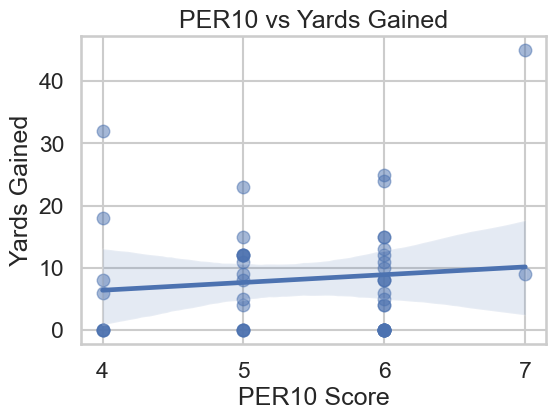

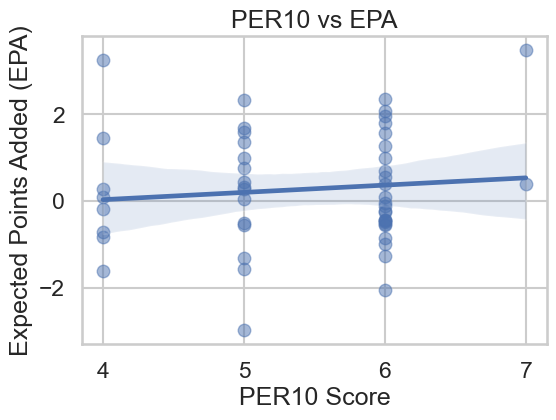

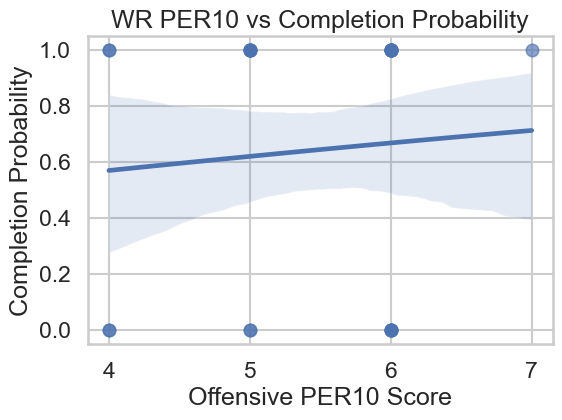

In [5]:
#plotting correlations of the stats for offense players
import seaborn as sns
import matplotlib.pyplot as plt


sns.set(style="whitegrid", context="talk")

# 1) PER10 vs Yards Gained
plt.figure(figsize=(6,4))
sns.regplot(x='PER10', y='yards_gained', data=off, scatter_kws={'alpha':0.5})
plt.title("PER10 vs Yards Gained")
plt.xlabel("PER10 Score")
plt.ylabel("Yards Gained")
plt.show()

# 2) PER10 vs EPA
plt.figure(figsize=(6,4))
sns.regplot(x='PER10', y='expected_points_added', data=off, scatter_kws={'alpha':0.5})
plt.title("PER10 vs EPA")
plt.xlabel("PER10 Score")
plt.ylabel("Expected Points Added (EPA)")
plt.show()


# 3) PER10 vs Completion Probability
plt.figure(figsize=(6,4))
sns.regplot(x='PER10', y='completed', data=off, logistic=True, scatter_kws={'alpha':0.4})
plt.title("WR PER10 vs Completion Probability")
plt.xlabel("Offensive PER10 Score")
plt.ylabel("Completion Probability")
plt.show()



In [6]:
#defense
db = df[df['player_side'] == 'Defense'].copy()
db[['PER10', 'yards_gained', 'expected_points_added']].head()


,PER10,yards_gained,expected_points_added
50,5,10,-0.105650
51,5,15,0.691294
52,4,45,3.481439
53,5,0,-0.190782
54,7,0,-0.716451


In [7]:
#compute Db correlations
db_corr = db[['PER10', 'yards_gained', 'expected_points_added']].corr()
db_corr


,PER10,yards_gained,expected_points_added
PER10,1.000000,-0.122391,-0.190741
yards_gained,-0.122391,1.000000,0.803607
expected_points_added,-0.190741,0.803607,1.000000


In [8]:
db['completed'] = (db['pass_result'] == 'C').astype(int)

db[['PER10', 'completed']].corr()

,PER10,completed
PER10,1.000000,0.073688
completed,0.073688,1.000000


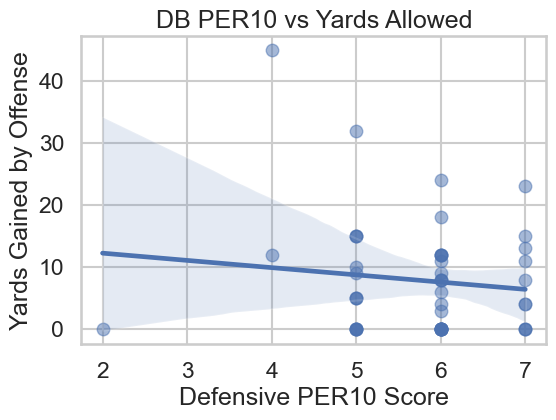

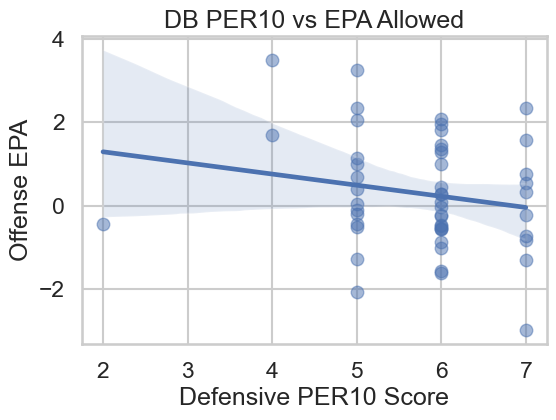

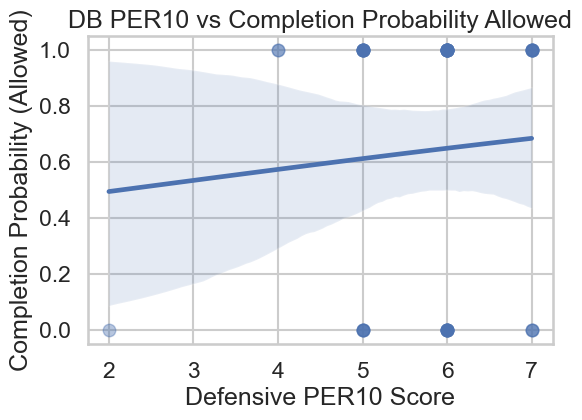

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", context="talk")

# PER10 vs yards gained (DB)
plt.figure(figsize=(6,4))
sns.regplot(x='PER10', y='yards_gained', data=db, scatter_kws={'alpha':0.5})
plt.title("DB PER10 vs Yards Allowed")
plt.xlabel("Defensive PER10 Score")
plt.ylabel("Yards Gained by Offense")
plt.show()

# PER10 vs EPA (DB)
plt.figure(figsize=(6,4))
sns.regplot(x='PER10', y='expected_points_added', data=db, scatter_kws={'alpha':0.5})
plt.title("DB PER10 vs EPA Allowed")
plt.xlabel("Defensive PER10 Score")
plt.ylabel("Offense EPA")
plt.show()



plt.figure(figsize=(6,4))
sns.regplot(x='PER10', y='completed', data=db, logistic=True, scatter_kws={'alpha':0.4})
plt.title("DB PER10 vs Completion Probability Allowed")
plt.xlabel("Defensive PER10 Score")
plt.ylabel("Completion Probability (Allowed)")
plt.show()

